# SpaGCN × Moffitt MERFISH — Unified Benchmark
**Author**: Mohammed | Bahçeşehir University – M.Sc. Computer Engineering

### Unified parameters (matched with DeepST notebook)
- `CELLS_PER_BREGMA = 50_000` — same sample cap as DeepST
- `N_CLUSTERS = 15` — matches ground-truth cell types & DeepST
- `SEED = 42` — single seed for all randomness (sampling + SpaGCN louvain + torch)
- Silhouette score added alongside ARI / NMI
- Runtime logged per slice (for thesis comparison table)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

print("Copying dataset locally (faster I/O)...")
!cp "/content/drive/MyDrive/Colab Notebooks/Datasets/cells_cleaned.csv" /content/cells_cleaned.csv
print("Done!")

Mounted at /content/drive
Copying dataset locally (faster I/O)...
Done!


In [2]:
!pip install SpaGCN scanpy louvain python-igraph torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 131.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 9.1 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of python-igraph to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 112.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 139.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.3/174.3 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 153.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 160.1 MB/s eta 0:00:00
  Created whee

In [3]:
# =============================================================================
# SpaGCN pipeline — Moffitt MERFISH
# Verified against SpaGCN 1.2.7 source + official tutorial (no-histology mode).
# Unified with DeepST notebook: same SEED, same CELLS_PER_BREGMA, same N_CLUSTERS.
# =============================================================================

import os, gc, time, random, warnings
import numpy as np
import pandas as pd
import psutil
import scanpy as sc
import SpaGCN as spg
import torch
from sklearn.metrics import (adjusted_rand_score,
                              normalized_mutual_info_score,
                              silhouette_score)
warnings.filterwarnings("ignore")

# =============================================================================
# ╔══════════════════════════════════════════╗
# ║           CONTROL PANEL                 ║
# ╚══════════════════════════════════════════╝
# =============================================================================

DATA_PATH        = "/content/cells_cleaned.csv"
OUTPUT_DIR       = "/content/drive/MyDrive/Colab Notebooks/Datasets/spagcn_results_50k"

CELLS_PER_BREGMA = 50_000   # unified with DeepST
N_CLUSTERS       = 15       # unified with DeepST — matches 15 Moffitt cell types
SEED             = 42       # single seed for sampling + SpaGCN (r/t/n_seed)

# SpaGCN-specific hyperparameters (unchanged from source defaults)
P          = 0.5    # target proportion for l search
L_START    = 0.01
L_END      = 1000
L_TOL      = 0.01
L_MAX_RUN  = 100
RES_START  = 0.7
RES_STEP   = 0.1
RES_TOL    = 5e-3
LR         = 0.05
MAX_EPOCHS = 200

# =============================================================================
# Column definitions
# =============================================================================

CELL_ID_COL = "Cell_ID"
BREGMA_COL  = "Bregma"
X_COL       = "Centroid_X"
Y_COL       = "Centroid_Y"
LABEL_COL   = "Cell_class"

GENE_COLS = [
    "Ace2","Adora2a","Aldh1l1","Amigo2","Ano3","Aqp4","Ar","Arhgap36",
    "Avpr1a","Avpr2","Baiap2","Bdnf","Bmp7","Brs3","Calcr","Cbln1","Cbln2",
    "Cckar","Cckbr","Ccnd2","Cd24a","Cdkn1a","Cenpe","Chat","Coch","Col25a1",
    "Cplx3","Cpne5","Creb3l1","Crhbp","Crhr1","Crhr2","Cspg5","Cxcl14",
    "Cyp19a1","Cyp26a1","Cyr61","Dgkk","Ebf3","Egr2","Ermn","Esr1","Etv1",
    "Fbxw13","Fezf1","Fn1","Fst","Gabra1","Gabrg1","Gad1","Galr1","Galr2",
    "Gbx2","Gda","Gem","Gjc3","Glra3","Gpr165","Greb1","Grpr","Htr2c",
    "Igf1r","Igf2r","Irs4","Isl1","Kiss1r","Klf4","Krt90","Lepr","Lmod1",
    "Lpar1","Man1a","Mc4r","Mki67","Mlc1","Myh11","Ndnf","Ndrg1","Necab1",
    "Nos1","Npas1","Npy1r","Npy2r","Ntng1","Ntsr1","Nup62cl","Omp","Onecut2",
    "Opalin","Oprd1","Oprk1","Oprl1","Oxtr","Pak3","Pcdh11x","Pdgfra","Pgr",
    "Plin3","Pnoc","Pou3f2","Prlr","Ramp3","Rgs2","Rgs5","Rnd3","Rxfp1",
    "Scgn","Selplg","Sema3c","Sema4d","Serpinb1b","Serpine1","Sgk1","Slc15a3",
    "Slc17a6","Slc17a7","Slc17a8","Slc18a2","Slco1a4","Sox4","Sox6","Sox8",
    "Sp9","Synpr","Syt2","Syt4","Sytl4","Tacr1","Tacr3","Tiparp","Tmem108",
    "Traf4","Trhr","Ttn","Ttyh2","Adcyap1","Cartpt","Cck","Crh","Gal",
    "Gnrh1","Mbp","Nnat","Nts","Oxt","Penk","Scg2","Sln","Sst","Tac1",
    "Tac2","Th","Trh","Ucn3","Vgf",
]

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Config ready.")
print(f"  CELLS_PER_BREGMA : {CELLS_PER_BREGMA:,}")
print(f"  N_CLUSTERS       : {N_CLUSTERS}")
print(f"  SEED             : {SEED}")

/usr/local/lib/python3.12/dist-packages/anndata/__init__.py:70: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/usr/local/lib/python3.12/dist-packages/anndata/__init__.py:70: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/usr/local/lib/python3.12/dist-packages/anndata/__init__.py:70: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)


Config ready.
  CELLS_PER_BREGMA : 50,000
  N_CLUSTERS       : 15
  SEED             : 42


In [4]:
# =============================================================================
# Helpers
# =============================================================================

def build_adata(slice_df):
    """Build AnnData from a single-bregma dataframe."""
    X     = slice_df[GENE_COLS].values.astype(np.float32)
    adata = sc.AnnData(X=X)
    adata.var_names = GENE_COLS
    adata.obs_names = slice_df[CELL_ID_COL].astype(str).values
    adata.obs["x_pixel"]   = slice_df[X_COL].values
    adata.obs["y_pixel"]   = slice_df[Y_COL].values
    adata.obs["true_label"] = slice_df[LABEL_COL].values
    return adata


def compute_metrics(adata):
    """ARI, NMI, Silhouette vs. ground truth."""
    true = adata.obs["true_label"].tolist()
    pred = adata.obs["pred"].tolist()
    ari  = adjusted_rand_score(true, pred)
    nmi  = normalized_mutual_info_score(true, pred, average_method="arithmetic")

    # Silhouette on PCA embedding (or raw expression if PCA not stored)
    sil = np.nan
    try:
        if "X_pca" in adata.obsm:
            embed = adata.obsm["X_pca"]
        else:
            embed = adata.X
        if len(set(pred)) > 1:          # silhouette undefined for 1 cluster
            sil = silhouette_score(embed, pred, sample_size=min(5000, len(pred)),
                                   random_state=SEED)
    except Exception:
        pass

    return round(ari, 4), round(nmi, 4), round(float(sil), 4)


def ram_gb():
    return psutil.virtual_memory().used / 1024**3

print("Helpers ready.")

Helpers ready.


In [5]:
# =============================================================================
# Load dataset once
# =============================================================================

print("Loading dataset ...")
df      = pd.read_csv(DATA_PATH)
bregmas = sorted(df[BREGMA_COL].unique())
print(f"  Total cells   : {len(df):,}")
print(f"  Bregma slices : {bregmas}")

Loading dataset ...
  Total cells   : 874,768
  Bregma slices : [np.float64(-0.29), np.float64(-0.24), np.float64(-0.19), np.float64(-0.14), np.float64(-0.09), np.float64(-0.04), np.float64(0.01), np.float64(0.06), np.float64(0.11), np.float64(0.16), np.float64(0.21), np.float64(0.26)]


In [6]:
# =============================================================================
# Main loop — one slice at a time
# =============================================================================

RESULTS_CSV = os.path.join(OUTPUT_DIR, "spagcn_summary.csv")

# Resume after crash: skip already-done bregmas
if os.path.exists(RESULTS_CSV):
    done_df      = pd.read_csv(RESULTS_CSV)
    all_results  = done_df.to_dict("records")
    done_bregmas = set(done_df[BREGMA_COL].tolist())
    print(f"Resuming — {len(done_bregmas)} slices already done: {sorted(done_bregmas)}")
else:
    all_results  = []
    done_bregmas = set()
    print("Starting fresh.")

total_ram      = psutil.virtual_memory().total / 1024**3
pipeline_start = time.time()
n_total_slices = len(bregmas)

for i, bregma in enumerate(bregmas):

    if bregma in done_bregmas:
        print(f"[{i+1}/{n_total_slices}] Bregma={bregma} — already done, skipping.")
        continue

    print("=" * 60)
    print(f"[{i+1}/{n_total_slices}] Bregma: {bregma}")
    print("=" * 60)

    slice_start = time.time()
    ram_before  = ram_gb()
    adata       = None

    slice_df = df[df[BREGMA_COL] == bregma].copy()
    n_total  = len(slice_df)
    print(f"  Cells in slice : {n_total:,}")

    if n_total > CELLS_PER_BREGMA:
        slice_df = slice_df.sample(n=CELLS_PER_BREGMA,
                                   random_state=SEED).reset_index(drop=True)
        print(f"  Downsampled to : {CELLS_PER_BREGMA:,} cells")
    else:
        print(f"  Using all      : {n_total:,} cells (below cap)")

    try:
        adata = build_adata(slice_df)
        adata.var_names_make_unique()

        # -- Preprocessing (SpaGCN official pipeline, no-histology mode) --------
        spg.prefilter_genes(adata, min_cells=3)
        spg.prefilter_specialgenes(adata)
        sc.pp.normalize_per_cell(adata)
        sc.pp.log1p(adata)

        # Store PCA for silhouette (optional, may skip if memory tight)
        try:
            sc.pp.pca(adata, n_comps=min(50, adata.n_vars - 1, adata.n_obs - 1))
        except Exception:
            pass

        x_pixel = adata.obs["x_pixel"].tolist()
        y_pixel = adata.obs["y_pixel"].tolist()

        print("  Building adjacency matrix ...")
        adj = spg.calculate_adj_matrix(x=x_pixel, y=y_pixel, histology=False)

        print("  Searching for l ...")
        l = spg.search_l(P, adj, start=L_START, end=L_END,
                         tol=L_TOL, max_run=L_MAX_RUN)

        print(f"  Searching resolution (target N_CLUSTERS={N_CLUSTERS}) ...")
        res = spg.search_res(
            adata, adj, l, N_CLUSTERS,
            start=RES_START, step=RES_STEP, tol=RES_TOL,
            lr=LR, max_epochs=20,
            r_seed=SEED, t_seed=SEED, n_seed=SEED      # unified single seed
        )

        print("  Training SpaGCN ...")
        random.seed(SEED)
        torch.manual_seed(SEED)
        np.random.seed(SEED)

        clf = spg.SpaGCN()
        clf.set_l(l)
        clf.train(
            adata, adj,
            init_spa=True, init="louvain",
            res=res, tol=RES_TOL, lr=LR, max_epochs=MAX_EPOCHS
        )
        y_pred, prob = clf.predict()
        adata.obs["pred"] = y_pred
        adata.obs["pred"] = adata.obs["pred"].astype("category")

        ari, nmi, sil  = compute_metrics(adata)
        n_domains      = adata.obs["pred"].nunique()
        ram_after      = ram_gb()
        slice_time     = time.time() - slice_start

        print(f"  Domains found  : {n_domains}")
        print(f"  ARI            : {ari}")
        print(f"  NMI            : {nmi}")
        print(f"  Silhouette     : {sil}")
        print(f"  Time           : {slice_time/60:.1f} min")
        print(f"  RAM before/after: {ram_before:.2f} / {ram_after:.2f} GB  [total {total_ram:.1f} GB]")

        # Save per-slice predictions
        out_df = pd.DataFrame({
            CELL_ID_COL   : adata.obs_names,
            BREGMA_COL    : bregma,
            X_COL         : adata.obs["x_pixel"].values,
            Y_COL         : adata.obs["y_pixel"].values,
            LABEL_COL     : adata.obs["true_label"].values,
            "pred_domain" : adata.obs["pred"].values,
        })
        out_df.to_csv(os.path.join(OUTPUT_DIR,
                      f"bregma_{bregma}_predictions.csv"), index=False)

        result = {
            BREGMA_COL        : bregma,
            "n_cells_total"   : n_total,
            "n_cells_used"    : len(slice_df),
            "n_domains_found" : n_domains,
            "l"               : round(l, 4),
            "res"             : round(res, 4),
            "ARI"             : ari,
            "NMI"             : nmi,
            "Silhouette"      : sil,
            "time_min"        : round(slice_time / 60, 2),
            "ram_before_GB"   : round(ram_before, 2),
            "ram_after_GB"    : round(ram_after, 2),
            "status"          : "OK",
        }

    except Exception as e:
        ram_after  = ram_gb()
        slice_time = time.time() - slice_start
        print(f"  [ERROR] {e}")
        result = {
            BREGMA_COL        : bregma,
            "n_cells_total"   : n_total,
            "n_cells_used"    : len(slice_df),
            "n_domains_found" : np.nan,
            "l"               : np.nan,
            "res"             : np.nan,
            "ARI"             : np.nan,
            "NMI"             : np.nan,
            "Silhouette"      : np.nan,
            "time_min"        : round(slice_time / 60, 2),
            "ram_before_GB"   : round(ram_before, 2),
            "ram_after_GB"    : round(ram_after, 2),
            "status"          : f"ERROR: {e}",
        }

    finally:
        if adata is not None:
            del adata
        del slice_df
        gc.collect()
        torch.cuda.empty_cache()

    all_results.append(result)
    done_bregmas.add(bregma)
    pd.DataFrame(all_results).to_csv(RESULTS_CSV, index=False)
    print(f"  ✅ Saved to CSV\n")

print(f"Loop done. {len(all_results)} slices processed.")

Starting fresh.
[1/12] Bregma: -0.29
  Cells in slice : 40,239
  Using all      : 40,239 cells (below cap)
  Building adjacency matrix ...
Calculateing adj matrix using xy only...
  Searching for l ...
Run 1: l [0.01, 1000], p [1.3113022e-06, 17120.164]
Run 2: l [0.01, 500.005], p [1.3113022e-06, 7050.476]
Run 3: l [0.01, 250.0075], p [1.3113022e-06, 2118.4038]
Run 4: l [0.01, 125.00874999999999], p [1.3113022e-06, 564.31824]
Run 5: l [0.01, 62.509375], p [1.3113022e-06, 144.35303]
Run 6: l [0.01, 31.2596875], p [1.3113022e-06, 36.261448]
Run 7: l [0.01, 15.63484375], p [1.3113022e-06, 8.882749]
Run 8: l [0.01, 7.822421875], p [1.3113022e-06, 2.0795813]
Run 9: l [3.9162109375, 7.822421875], p [0.46484876, 2.0795813]
Run 10: l [3.9162109375, 5.86931640625], p [0.46484876, 1.1237206]
Run 11: l [3.9162109375, 4.8927636718750005], p [0.46484876, 0.75696075]
Run 12: l [3.9162109375, 4.4044873046875], p [0.46484876, 0.6014633]
Run 13: l [3.9162109375, 4.16034912109375], p [0.46484876, 0.5307

In [7]:
# =============================================================================
# Final summary
# =============================================================================

summary_df = pd.read_csv(RESULTS_CSV)
ok = summary_df[summary_df["status"] == "OK"]

print("=" * 60)
print("  SpaGCN — Moffitt MERFISH — All Bregma Slices")
print("=" * 60)
print(summary_df[["Bregma","n_cells_used","n_domains_found",
                   "ARI","NMI","Silhouette","time_min"]].to_string(index=False))
print("=" * 60)

if len(ok):
    total_min = ok["time_min"].sum()
    print(f"  Mean ARI        : {ok['ARI'].mean():.4f} ± {ok['ARI'].std():.4f}")
    print(f"  Mean NMI        : {ok['NMI'].mean():.4f} ± {ok['NMI'].std():.4f}")
    print(f"  Mean Silhouette : {ok['Silhouette'].mean():.4f} ± {ok['Silhouette'].std():.4f}")
    print(f"  Total time      : {total_min:.1f} min ({total_min/60:.1f} h)")
    print(f"  Slices OK / total : {len(ok)} / {len(summary_df)}")

# Thesis summary row
thesis = pd.DataFrame([{
    "Method"        : "SpaGCN",
    "Dataset"       : "Moffitt_MERFISH",
    "Slices"        : len(ok),
    "Cells_per_slice": CELLS_PER_BREGMA,
    "N_clusters"    : N_CLUSTERS,
    "Seed"          : SEED,
    "Mean_ARI"      : round(ok["ARI"].mean(), 4),
    "Std_ARI"       : round(ok["ARI"].std(), 4),
    "Mean_NMI"      : round(ok["NMI"].mean(), 4),
    "Std_NMI"       : round(ok["NMI"].std(), 4),
    "Mean_Silhouette": round(ok["Silhouette"].mean(), 4),
    "Total_time_min": round(ok["time_min"].sum(), 2),
}])
thesis.to_csv(os.path.join(OUTPUT_DIR, "spagcn_thesis_summary.csv"), index=False)
print("\nThesis summary saved: spagcn_thesis_summary.csv")
print(thesis.to_string(index=False))

  SpaGCN — Moffitt MERFISH — All Bregma Slices
 Bregma  n_cells_used  n_domains_found    ARI    NMI  Silhouette  time_min
  -0.29         40239               15 0.3718 0.5367      0.0914     11.14
  -0.24         36919               15 0.3189 0.5381      0.0868      6.79
  -0.19         41766               15 0.3429 0.5204      0.0753     13.78
  -0.14         42453               14 0.2856 0.5046      0.0611      9.39
  -0.09         40979               15 0.3409 0.5310      0.0739     12.93
  -0.04         41778               14 0.3399 0.5309      0.0853     14.36
   0.01         30020               15 0.3939 0.5541      0.0970      4.56
   0.06         29053               15 0.4576 0.5687      0.0812      5.07
   0.11         50000               15 0.3483 0.5311      0.0270     12.03
   0.16         50000               14 0.3892 0.5249      0.0295     10.94
   0.21         50000               14 0.3457 0.4817      0.0585     20.57
   0.26         50000               15 0.3501 0.4889 

Chart saved.


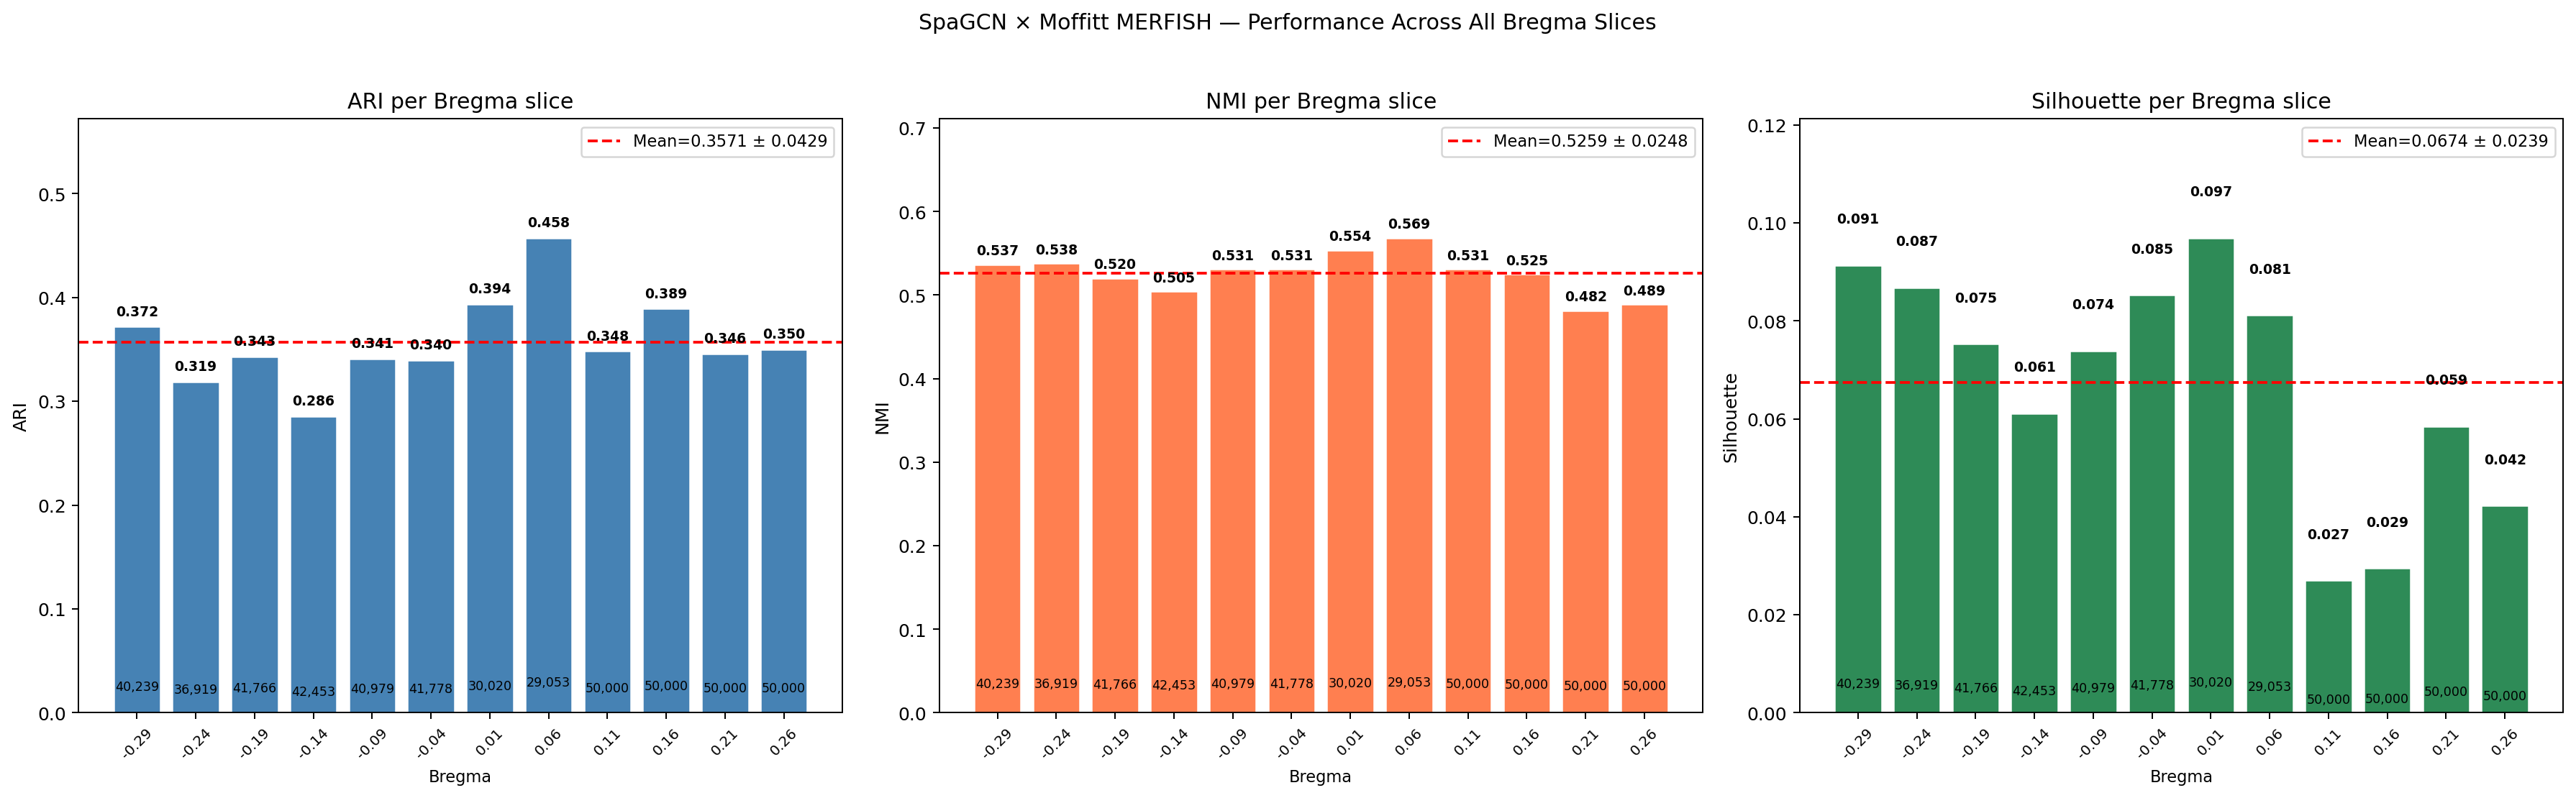

In [11]:
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import Image as IPImage

summary_df = pd.read_csv(RESULTS_CSV)
x = [str(b) for b in summary_df['Bregma']]
n_cells = summary_df['n_cells_used'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, metric, color in [
    (axes[0], 'ARI',        'steelblue'),
    (axes[1], 'NMI',        'coral'),
    (axes[2], 'Silhouette', 'seagreen'),
]:
    bars = ax.bar(x, summary_df[metric], color=color, edgecolor='white')
    mean_val = summary_df[metric].mean()
    std_val  = summary_df[metric].std()
    ax.axhline(mean_val, color='red', linestyle='--',
               label=f'Mean={mean_val:.4f} ± {std_val:.4f}')

    for bar, val, n in zip(bars, summary_df[metric], n_cells):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 0.05,
                f'{n:,}', ha='center', va='bottom', fontsize=7, color='black')

    ax.set_xticks(range(len(x)))
    ax.set_xticklabels(x, fontsize=8, rotation=45)
    ax.set_title(f'{metric} per Bregma slice', fontsize=12)
    ax.set_xlabel('Bregma', fontsize=9)
    ax.set_ylabel(metric)
    ax.set_ylim(0, summary_df[metric].max() * 1.25)
    ax.legend(fontsize=9)

plt.suptitle('SpaGCN × Moffitt MERFISH — Performance Across All Bregma Slices',
             fontsize=12, y=1.02)
plt.tight_layout()

chart_path = os.path.join(OUTPUT_DIR, 'allslices_metrics.png')
plt.savefig(chart_path, dpi=180, bbox_inches='tight')
plt.close()
print('Chart saved.')

IPImage(chart_path)